In [30]:
import time
import numpy as np
from pynq import Overlay, allocate

# ============================================================
# FIXED POINT HELPERS
# ============================================================

def float_to_q824(x):
    return int(np.round(x * (1 << Q_FRAC_BITS)))

def q824_to_float(x):
    return x / float(1 << Q_FRAC_BITS)

# ============================================================
# PACKED INTERFACE
# ============================================================

job_dtype = np.dtype([
    ("word", np.uint64, 2)      # 128 bits
])

result_dtype = np.dtype([
    ("word", np.uint64, 1)      # 64 bits
])

# ============================================================
# PACKING
# ============================================================

def pack_job(values):

    packed = 0

    for i, v in enumerate(values):
        packed |= (
            int(np.uint32(v))
            << (32 * i)
        )

    return np.array([
        packed & ((1 << 64) - 1),
        (packed >> 64) & ((1 << 64) - 1)
    ], dtype=np.uint64)

def unpack_result(word, convert=False):

    packed = int(word)

    out = []

    for i in range(NUM_OUTPUTS):

        v = (
            packed >> (32 * i)
        ) & 0xffffffff

        if v & 0x80000000:
            v -= 0x100000000

        if convert:
            out.append(q824_to_float(v))
        else:
            out.append(v)

    return out


# ============================================================
# BUILD FPGA JOBS
# ============================================================

def build_jobs(state, jobs):
    for job in range(N):
        base = job * NUM_INPUTS
        inp = np.array([
            float_to_q824(state[base + 0]),  # u
            float_to_q824(state[base + 1]),  # v
            float_to_q824(state[base + 2]),  # I
        ], dtype=np.int32)

        jobs[job]["word"][:] = pack_job(inp)


# ============================================================
# FPGA EXECUTION
# ============================================================

def run_accelerator():
    jobs.flush()

    # Sends memory location of jobs to fpga
    accel.write(0x10, jobs.physical_address)
    
    # Sends mem loc of results to fpga
    accel.write(0x1C, results.physical_address)

    # Sends number of jobs to fpga
    accel.write(0x28, N)

    # Tells fpga to start computation
    accel.write(0x00, 1)

    # Waits for results
    while (accel.read(0x00) & 0x2) == 0:
        pass

    # Invalidate local cache for results (This forces CPU to fetch it from RAM again)
    results.invalidate()

# ============================================================
# CONFIGURATION
# ============================================================

BITFILE = "design_1.bit"

NUM_INPUTS = 3      # u, v, I
NUM_OUTPUTS = 2     # u, v

Q_FRAC_BITS = 24
Q = 1 << Q_FRAC_BITS

DT = 1e-3
T_END = 20

A = .7
EPSILON = .1
INV_E = 1.0 / EPSILON
TEMPERATURE = 0 * 5E-2

D = TEMPERATURE / EPSILON
SIGMA = np.sqrt(2 * D)
SIGMA_SQRT_DT = SIGMA * np.sqrt(DT)

SEED = 12345678

N = 8
    
# ============================================================
# LOAD BITSTREAM
# ============================================================

ol = Overlay(BITFILE)
accel = ol.accelerator_0

print(accel.register_map)

accel.register_map.dt = float_to_q824(DT)
accel.register_map.a = float_to_q824(A)
accel.register_map.inv_e = float_to_q824(INV_E)
accel.register_map.sigma_sqrt_dt = float_to_q824(SIGMA_SQRT_DT)
accel.register_map.seed = SEED
accel.register_map.reseed = 1

jobs = allocate(
    shape=(N,),
    dtype=job_dtype
)

results = allocate(
    shape=(N,),
    dtype=result_dtype
)

# ============================================================
# INITIAL CONDITIONS
# ============================================================

u0 = np.int32(float_to_q824(0.0))
v0 = np.int32(float_to_q824(0.0))
I0 = np.int32(float_to_q824(0.0))

# Todo check this
build_jobs([u0, v0, I0] * N, jobs)
    
# ============================================================
# SIMULATION
# ============================================================

num_steps = int(T_END / DT)

fpga_time = 0.0
total_time = 0.0

# Benchmark total time
t2 = time.perf_counter()

traj_packed = []

for step in range(num_steps):
    
    # Benchmark and run accelerator
    t0 = time.perf_counter()
    run_accelerator()
    t1 = time.perf_counter()
    fpga_time += t1 - t0
    
    # We disable reseeding after the first step
    if step == 0:
        accel.register_map.reseed = 0
        
    # Copy result to next inputs
    jobs["word"][:,0] = results["word"]
    # Set external input to zero for all times after first
    jobs["word"][:,1] = 0
    traj_packed.append(results["word"].copy())

# Benchmark total time
t3 = time.perf_counter()
total_time = t3 - t2


total_jobs = N * num_steps

print()
print("================================")
print("Simulation completed")
print("================================")
print(f"N             : {N}")
print(f"Steps         : {num_steps}")
print(f"Total jobs    : {total_jobs}")
print()
print("Timing breakdown")
print("------------------------------")
print(
    f"FPGA          : "
    f"{fpga_time:.6f} s"
)
print(
    f"Feedback copy : "
    f"{total_time - fpga_time:.6f} s"
)
print(
    f"Total         : "
    f"{total_time:.6f} s"
)
print()
print("Throughput")
print("------------------------------")
print(
    f"FPGA MJobs/s  : "
    f"{total_jobs/fpga_time/1e6:.3f}"
)
print(
    f"End-to-end    : "
    f"{total_jobs/total_time/1e6:.3f}"
)
print("================================")

jobs.close()
results.close()

/tmp/ipykernel_7374/438061495.py:23: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  result_dtype = np.dtype([


RegisterMap {
  CTRL = Register(AP_START=0, AP_DONE=0, AP_IDLE=1, AP_READY=0, RESERVED_1=0, AUTO_RESTART=0, RESERVED_2=0, INTERRUPT=0, RESERVED_3=0),
  GIER = Register(Enable=0, RESERVED=0),
  IP_IER = Register(CHAN0_INT_EN=0, CHAN1_INT_EN=0, RESERVED_0=0),
  IP_ISR = Register(CHAN0_INT_ST=0, CHAN1_INT_ST=0, RESERVED_0=0),
  jobs_1 = Register(jobs=write-only),
  jobs_2 = Register(jobs=write-only),
  results_1 = Register(results=write-only),
  results_2 = Register(results=write-only),
  num_jobs = Register(num_jobs=write-only),
  dt = Register(dt=write-only),
  a = Register(a=write-only),
  inv_e = Register(inv_e=write-only),
  sigma_sqrt_dt = Register(sigma_sqrt_dt=write-only),
  seed = Register(seed=write-only),
  reseed = Register(reseed=write-only, RESERVED=write-only)
}

Simulation completed
N             : 8
Steps         : 20000
Total jobs    : 160000

Timing breakdown
------------------------------
FPGA          : 13.132176 s
Feedback copy : 23.586060 s
Total         : 36.718236

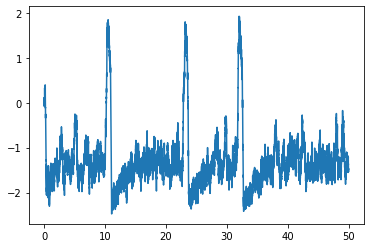

In [26]:
import matplotlib.pyplot as plt
import numpy as np

traj_packed = np.array(traj_packed)
vals = list(map(lambda x: unpack_result(x, True)[0], traj_packed[:,0]))

xpoints = np.linspace(0, T_END, len(vals))
ypoints = np.array(vals)

plt.plot(xpoints, ypoints)
plt.show()

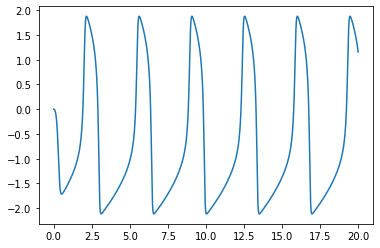

In [33]:
vals = list(map(lambda x: unpack_result(x, True)[0], traj_packed[:,1]))

xpoints = np.linspace(0, T_END, len(vals))
ypoints = np.array(vals)

plt.plot(xpoints, ypoints)
plt.show()

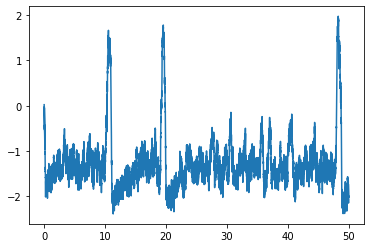

In [27]:
vals = list(map(lambda x: unpack_result(x, True)[0], traj_packed[:,2]))

xpoints = np.linspace(0, T_END, len(vals))
ypoints = np.array(vals)

plt.plot(xpoints, ypoints)
plt.show()

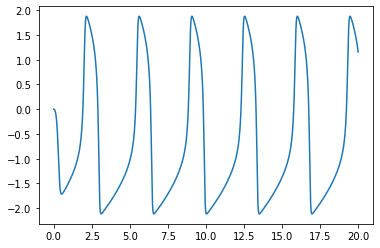

In [34]:
vals = list(map(lambda x: unpack_result(x, True)[0], traj_packed[:,3]))

xpoints = np.linspace(0, T_END, len(vals))
ypoints = np.array(vals)

plt.plot(xpoints, ypoints)
plt.show()

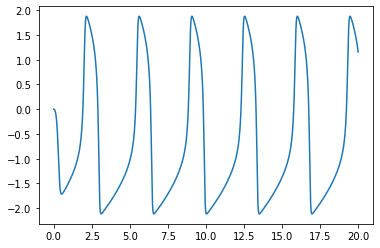

In [35]:
vals = list(map(lambda x: unpack_result(x, True)[0], traj_packed[:,4]))

xpoints = np.linspace(0, T_END, len(vals))
ypoints = np.array(vals)

plt.plot(xpoints, ypoints)
plt.show()